# Random forest Hyper parameter tunning

In [5]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import accuracy_score, make_scorer

# Load the dataset
data = pd.read_csv('60k_dataframe.csv')

# Split the dataset into features and target variable
# Split the dataset into features and target variable
X = data.iloc[:, 1:] # features
y = data.iloc[:, 0] # target variable

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

# Define the model
rfc = RandomForestClassifier(random_state=42)

# Define the hyperparameter grid for random search
param_dist = {
    'n_estimators': [100, 300, 500, 800, 1200],
    'max_depth': [5, 8, 15, 25, 30, None],
    'min_samples_split': [2, 5, 10, 15, 100],
    'min_samples_leaf': [1, 2, 5, 10],
    'bootstrap': [True, False]
}

# Define the random search object
random_search = RandomizedSearchCV(
    estimator=rfc,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring=make_scorer(accuracy_score),
    n_jobs=-1
)

# Perform the random search to find the best hyperparameters
random_search.fit(X_train, y_train)

# Print the best hyperparameters and accuracy score
print('Best hyperparameters:', random_search.best_params_)
print('Accuracy score:', random_search.best_score_)


Best hyperparameters: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 25, 'bootstrap': False}
Accuracy score: 0.9004399856230455


## 2. Test for Hyper parameter Improvement

In [4]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, make_scorer

# Load the dataset
data = pd.read_csv('60k_dataframe.csv')

# Split the dataset into features and target variable
# Split the dataset into features and target variable
X = data.iloc[:, 1:] # features
y = data.iloc[:, 0] # target variable

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

# Define the model
rfc = RandomForestClassifier(random_state=42)

# Define the hyperparameter grid for grid search
param_grid = {
    'bootstrap': [False,],
    'max_depth': [None,],
    'min_samples_leaf': [1, 2, 3],
    'min_samples_split': [3, 5, 7],
    'n_estimators': [800, 850, 900]
}

grid_search = GridSearchCV(estimator = rfc, param_grid = param_grid, 
                          cv = 3, n_jobs = -1, verbose = 2)


# Perform the random search to find the best hyperparameters
grid_search.fit(X_train, y_train)

# Print the best hyperparameters and accuracy score
print('Best hyperparameters:', random_search.best_params_)
print('Accuracy score:', random_search.best_score_)


Fitting 3 folds for each of 27 candidates, totalling 81 fits
[CV] END bootstrap=False, max_depth=None, min_samples_leaf=1, min_samples_split=3, n_estimators=800; total time= 5.3min
[CV] END bootstrap=False, max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=800; total time= 5.5min
[CV] END bootstrap=False, max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=900; total time= 6.3min
[CV] END bootstrap=False, max_depth=None, min_samples_leaf=2, min_samples_split=3, n_estimators=800; total time= 5.8min
[CV] END bootstrap=False, max_depth=None, min_samples_leaf=2, min_samples_split=3, n_estimators=900; total time= 6.5min
[CV] END bootstrap=False, max_depth=None, min_samples_leaf=2, min_samples_split=5, n_estimators=850; total time= 6.1min
[CV] END bootstrap=False, max_depth=None, min_samples_leaf=2, min_samples_split=7, n_estimators=850; total time= 6.3min
[CV] END bootstrap=False, max_depth=None, min_samples_leaf=3, min_samples_split=3, n_estimators=850

## 3. Training with the tuned hyper parameters to find the optimal accuracy for Random Forest on 60k dataset

Started...
RF train roc-auc: 1.0
Confusion Matrix :  [[4364 1026]
 [  88 5940]]
Precision Score :  0.8527131782945736
Recall Score :  0.9854014598540146
Accuracy Score :  0.9024347521457348
F1 Score :  0.9142681237494228
RF test ROC AUC=0.958
Time Taken to train and test :  318.6879861354828


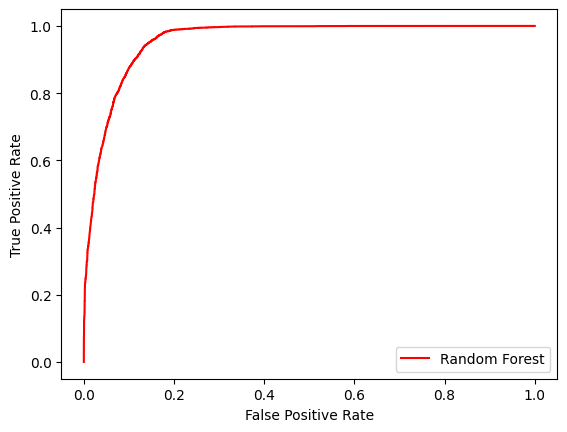

In [4]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import accuracy_score, make_scorer, roc_auc_score, precision_score, \
                                recall_score, confusion_matrix, f1_score, roc_curve
from matplotlib import pyplot
import time


print("Started...")

# Load the dataset
data = pd.read_csv('60k_dataframe.csv')

# Split the dataset into features and target variable
# Split the dataset into features and target variable
X = data.iloc[:, 1:] # features
y = data.iloc[:, 0] # target variable

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

optimal_params_frm_GS = {'n_estimators': 800, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': None, 'bootstrap': False}

# Define the model

start_time = time.time()

## Apply RandomForestClassifier
rf_model = RandomForestClassifier(**optimal_params_frm_GS, random_state=42)
rf_model.fit(X_train, y_train)
ytrain_pred = rf_model.predict_proba(X_train)
print('RF train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = rf_model.predict_proba(X_test)
# keep probabilities for the positive outcome only
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = rf_model.predict(X_test)
rf_conf_matx = confusion_matrix(y_test, y_pred)
rf_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", rf_conf_matx)
print("Precision Score : ", precision_score(y_test, y_pred))
print("Recall Score : ", recall_score(y_test, y_pred))
print("Accuracy Score : ", accuracy_score(y_test, y_pred))
print("F1 Score : ", rf_f1_score)

# summarize scores
print('RF test ROC AUC=%.3f' % (auc_score))
rf_fpr, rf_tpr, thresholds = roc_curve(y_test, ytest_pred)
# Saving the model
# file_name = f"{folder_name}/radom_forest_model.sav"
# pickle.dump(rf_model, open(file_name, "wb"))

print("Time Taken to train and test : ", time.time() - start_time)


# plot the roc curve for the model
pyplot.plot(rf_fpr, rf_tpr, color="red", label='Random Forest')

# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
# show the legend
pyplot.legend()
#save the image
# pyplot.savefig(f'{folder_name}/roc_auc_curve.svg', format='svg')
# show the plot
pyplot.show()


Started...
RF train roc-auc: 1.0
Confusion Matrix :  [[2004  408]
 [  27 2594]]
Precision Score :  0.8640906062624917
Recall Score :  0.9896985883250667
Accuracy Score :  0.9135704351281542
F1 Score :  0.922639160590432
RF test ROC AUC=0.974
Time Taken to train and test :  64.06268215179443


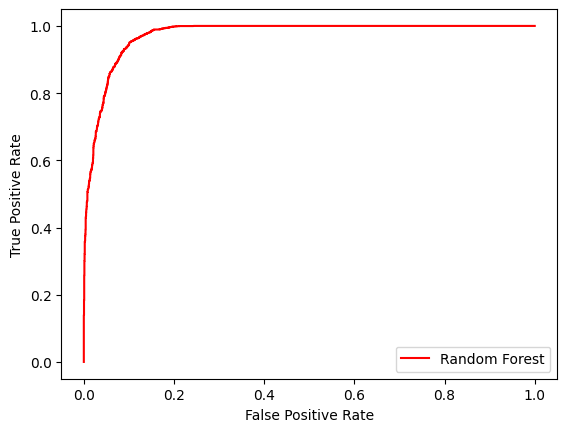

In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import accuracy_score, make_scorer, roc_auc_score, precision_score, \
                                recall_score, confusion_matrix, f1_score, roc_curve
from matplotlib import pyplot
import time


print("Started...")

# Load the dataset
data = pd.read_csv('20k_dataframe_2303.csv')

# Split the dataset into features and target variable
# Split the dataset into features and target variable
X = data.iloc[:, 1:] # features
y = data.iloc[:, 0] # target variable

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, shuffle=True)

optimal_params_frm_GS = {'n_estimators': 800, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': None, 'bootstrap': False}

# Define the model

start_time = time.time()

## Apply RandomForestClassifier
rf_model = RandomForestClassifier(**optimal_params_frm_GS, random_state=42)
rf_model.fit(X_train, y_train)
ytrain_pred = rf_model.predict_proba(X_train)
print('RF train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = rf_model.predict_proba(X_test)
# keep probabilities for the positive outcome only
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = rf_model.predict(X_test)
rf_conf_matx = confusion_matrix(y_test, y_pred)
rf_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", rf_conf_matx)
print("Precision Score : ", precision_score(y_test, y_pred))
print("Recall Score : ", recall_score(y_test, y_pred))
print("Accuracy Score : ", accuracy_score(y_test, y_pred))
print("F1 Score : ", rf_f1_score)

# summarize scores
print('RF test ROC AUC=%.3f' % (auc_score))
rf_fpr, rf_tpr, thresholds = roc_curve(y_test, ytest_pred)
# Saving the model
# file_name = f"{folder_name}/radom_forest_model.sav"
# pickle.dump(rf_model, open(file_name, "wb"))

print("Time Taken to train and test : ", time.time() - start_time)


# plot the roc curve for the model
pyplot.plot(rf_fpr, rf_tpr, color="red", label='Random Forest')

# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
# show the legend
pyplot.legend()
#save the image
# pyplot.savefig(f'{folder_name}/roc_auc_curve.svg', format='svg')
# show the plot
pyplot.show()


Started...
KNN train roc-auc: 1.0


/Users/bisalgt/Projects/playground/env/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


KNN test roc-auc: 0.5575102327953181


/Users/bisalgt/Projects/playground/env/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Confusion Matrix :  [[ 964 2683]
 [  82 3454]]
Precision Score :  0.5628157080006518
Recall Score :  0.9768099547511312
Accuracy Score :  0.6150633440066825
F1 Score :  0.7141527964437093
Time Taken to train and test :  1.9067602157592773


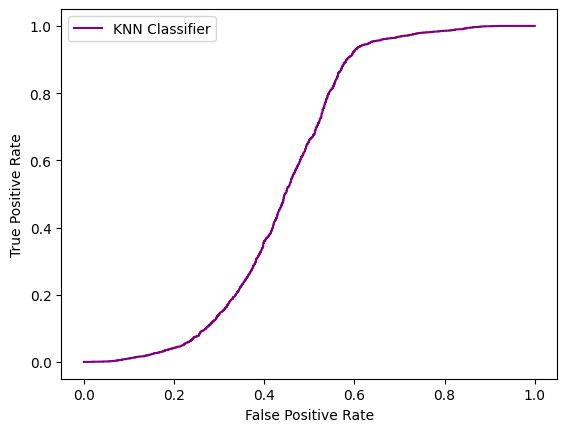

In [4]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import accuracy_score, make_scorer, roc_auc_score, precision_score, \
                                recall_score, confusion_matrix, f1_score, roc_curve
from matplotlib import pyplot
import time
import pickle

print("Started...")

folder_name = "final_trained_knn"

# Load the dataset
data = pd.read_csv('2203_test_dataframe.csv', header=None)

# Split the dataset into features and target variable
# Split the dataset into features and target variable
X_test = data.iloc[:, 1:] # features
y_test = data.iloc[:, 0] # target variable


# For test data we transform based on fitting on training data. It is taken from RAM, not initialized here
# X_test = min_max_scaler.transform(X_test)


start_time = time.time()
# Use the pretrained available on RAM -  KNN Classifier

ytrain_pred = rf_model.predict_proba(X_train)
print('KNN train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = rf_model.predict_proba(X_test)
print('KNN test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))
# Taking prediciton of positive class only
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = rf_model.predict(X_test)
rf_conf_matx = confusion_matrix(y_test, y_pred)
rf_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", rf_conf_matx)
print("Precision Score : ", precision_score(y_test, y_pred))
print("Recall Score : ", recall_score(y_test, y_pred))
print("Accuracy Score : ", accuracy_score(y_test, y_pred))
print("F1 Score : ", rf_f1_score)
# summarize scores
fpr, tpr, _ = roc_curve(y_test, ytest_pred)

print("Time Taken to train and test : ", time.time() - start_time)


# plot the roc curve for the model
pyplot.plot(fpr, tpr, color="purple", label='KNN Classifier')

# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
# show the legend
pyplot.legend()
#save the image
# pyplot.savefig(f'{folder_name}/test_roc_auc_curve.svg', format='svg')
# # show the plot
pyplot.show()


